## Fraud Detection in Credit Card Transactions

In [ ]:
## Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

import joblib

In [ ]:
## Load Dataset

df = pd.read_csv("creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [5]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

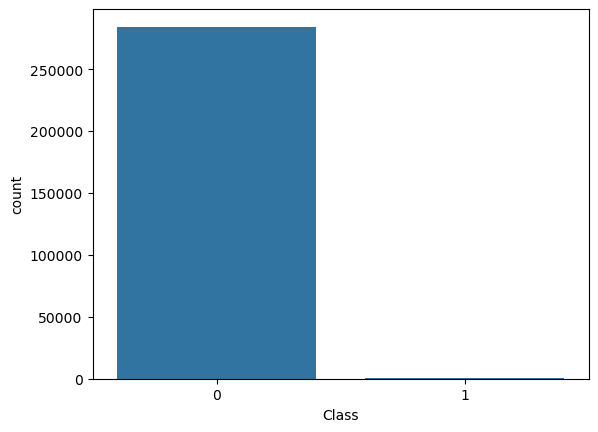

In [6]:
sns.countplot(x="Class", data=df)
plt.show()

In [7]:
## Exploratory Data Analysis

fraud_percentage = (
    df["Class"].value_counts(normalize=True) * 100
)

print(fraud_percentage)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


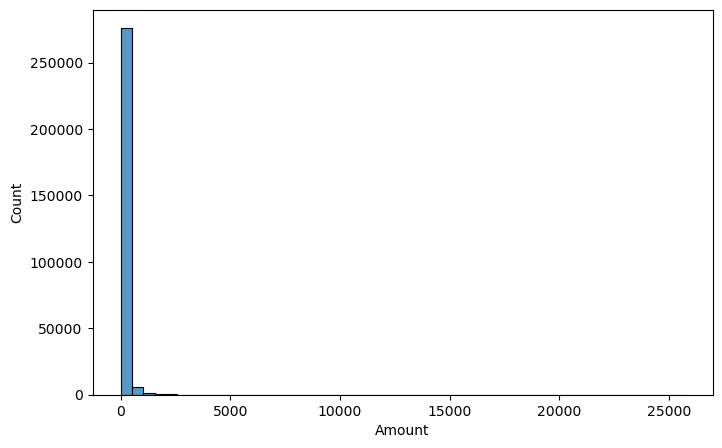

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["Amount"], bins=50)

plt.show()

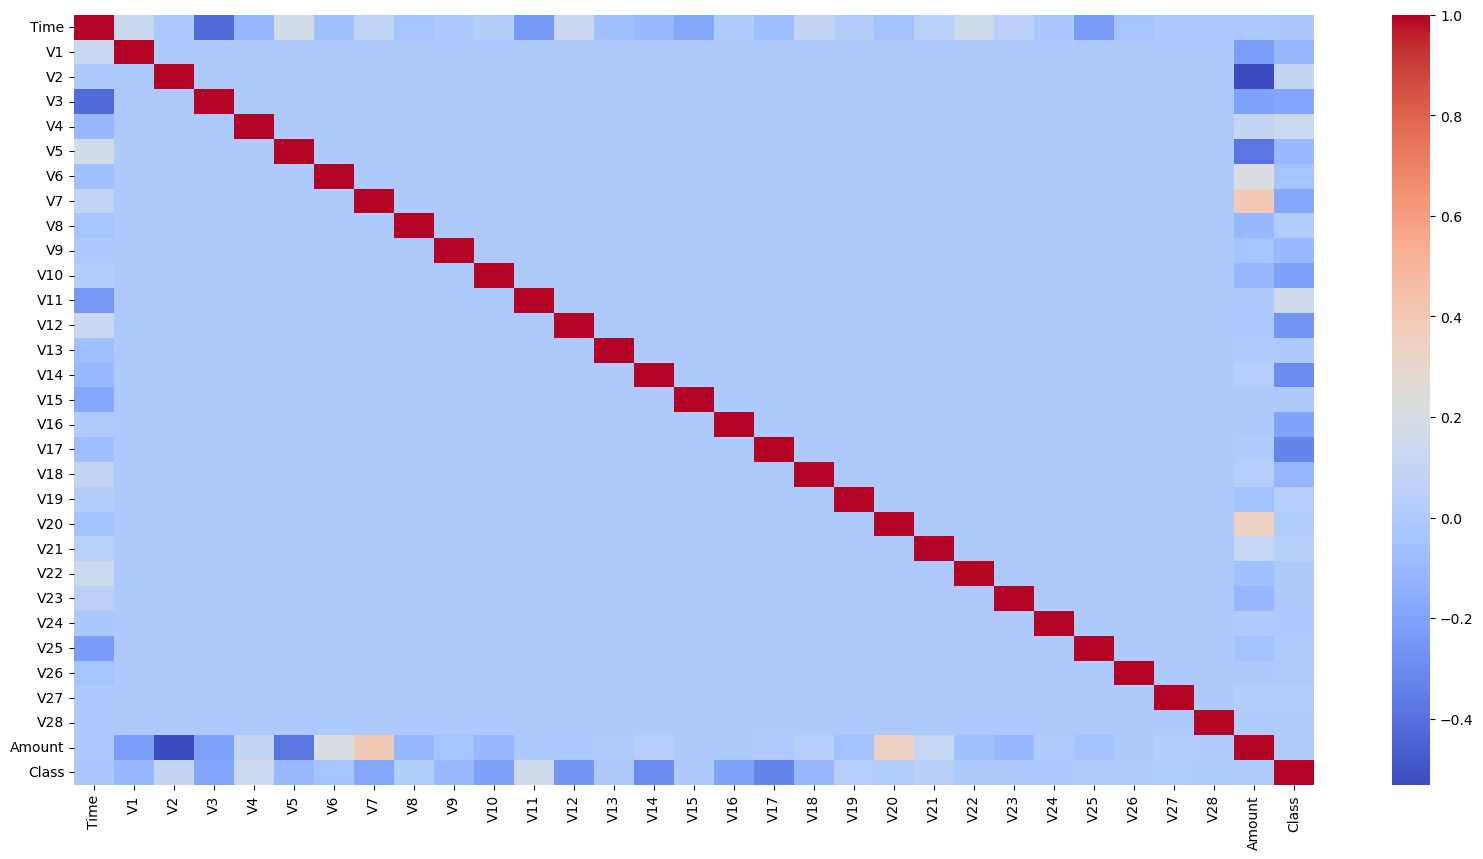

In [9]:
plt.figure(figsize=(20,10))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.show()

In [ ]:
## Feature Scaling

amount_scaler = StandardScaler()
time_scaler = StandardScaler()

df["scaled_amount"] = amount_scaler.fit_transform(df[["Amount"]])

df["scaled_time"] = time_scaler.fit_transform(df[["Time"]])

In [12]:
df.drop(["Time", "Amount"], axis=1, inplace=True)

In [13]:
scaled_amount = df.pop("scaled_amount")
scaled_time = df.pop("scaled_time")

df.insert(0, "scaled_amount", scaled_amount)
df.insert(1, "scaled_time", scaled_time)

In [14]:
## Split Features and Target

X = df.drop("Class", axis=1)
y = df["Class"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
## Balance the Training Data

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [17]:
pd.Series(y_train_smote).value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

In [18]:
## Anomaly Detection Models

# 1. Isolation Forest

iso = IsolationForest(
    contamination=0.0017,
    random_state=42
)

iso.fit(X_train)

IsolationForest(contamination=0.0017, random_state=42)

In [19]:
iso_pred = iso.predict(X_test)

iso_pred = np.where(iso_pred == -1, 1, 0)

In [20]:
print(confusion_matrix(y_test, iso_pred))

print(classification_report(y_test, iso_pred))

[[56786    78]
 [   65    33]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.30      0.34      0.32        98

    accuracy                           1.00     56962
   macro avg       0.65      0.67      0.66     56962
weighted avg       1.00      1.00      1.00     56962



In [21]:
# 2. Local Outlier Factor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.0017
)

lof_pred = lof.fit_predict(X_test)

lof_pred = np.where(lof_pred == -1, 1, 0)

In [22]:
print(confusion_matrix(y_test, lof_pred))

print(classification_report(y_test, lof_pred))

[[56769    95]
 [   96     2]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.02      0.02      0.02        98

    accuracy                           1.00     56962
   macro avg       0.51      0.51      0.51     56962
weighted avg       1.00      1.00      1.00     56962



In [23]:
## Train XGBoost Classifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(
    X_train_smote,
    y_train_smote
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [24]:
y_pred = xgb_model.predict(X_test)

y_prob = xgb_model.predict_proba(X_test)[:, 1]

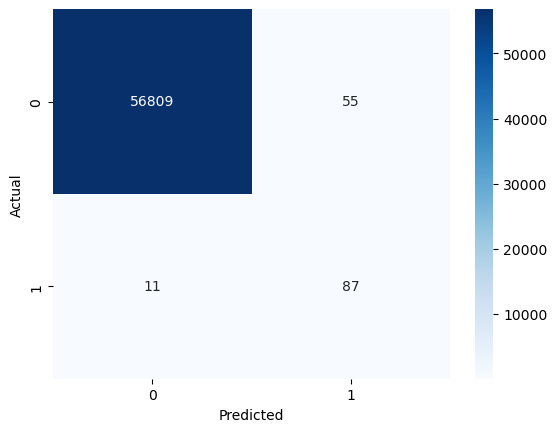

In [25]:
## Model Evaluation

# Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [26]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.61      0.89      0.72        98

    accuracy                           1.00     56962
   macro avg       0.81      0.94      0.86     56962
weighted avg       1.00      1.00      1.00     56962



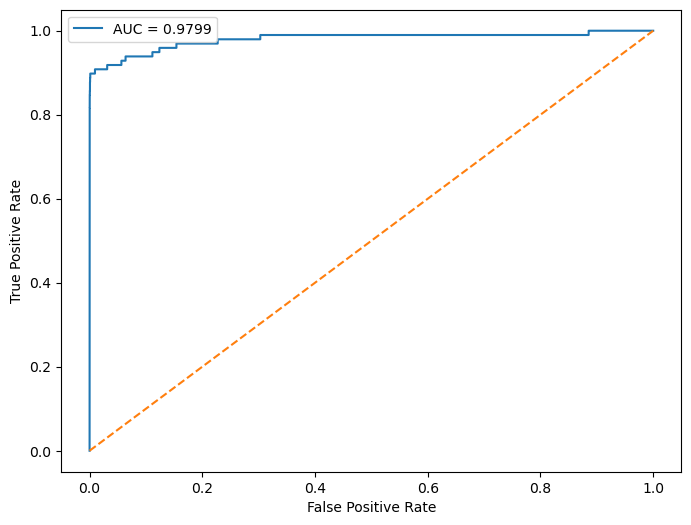

In [27]:
# ROC Curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

auc_score = roc_auc_score(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

In [ ]:
import os
import joblib

# Create models directory if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save models

joblib.dump(xgb_model, "models/xgboost_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(iso, "models/isolation_forest.pkl")

['models/isolation_forest.pkl']

In [31]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.load_model("models/xgboost_model.json")

XGBoostError: [21:07:00] D:\bld\xgboost-split_1780806776065\work\src\common\io.cc:144: Opening models/xgboost_model.json failed: The system cannot find the file specified.